# Costo local, no-reentrada, barrido de α y la brecha de convención

**Cómo leerlo.** Dos partes que no se mezclan. La **parte I** (§1–§8) son los
resultados cerrados de la semana del 18 de agosto: costo local (B-M6),
contraejemplo de no-reentrada (B-M16), flag de alcance y barrido V/C^α — todos
bajo la convención **estricta** vigente cuando se construyeron. La **parte II**
(§9–§12) es lo que cambió con la ratificación de G0 (posterior-zero,
31-ago) y el solver exacto B-M17 como testigo: la segunda vía, la brecha de
convención que cambia la política, el empate exacto en B = 3, y el candidato
C3 de la misión de búsqueda, con su estatuto.

**Estatuto.** El barrido de α y el candidato C3 son diagnósticos, no selección
de candidata: la adopción pasa por G4a/G4b. Los resultados de la parte I
siguen siendo correctos como **variante estricta** (columna del harness,
pregunta 21 de §34).

**Procedencia.** Cada número se regenera en su celda o se lee de un artefacto
versionado con sidecar; sin Monte Carlo. Nada escrito a mano.

**Los tres regímenes, con sus nombres completos.** Se distinguen siempre:
**estático** (las pruebas se fijan de antemano), **dinámico binario**
(adaptativo, la prueba responde si hay o no al menos un infectado) y **dinámico
aumentado** (adaptativo, la prueba devuelve el conteo de infectados). Todo el
notebook vive en el dinámico aumentado.

Convención: `q` es la probabilidad de estar **sano**. El régimen de interés es
`q < 0.5`, o sea prevalencia alta. Un resultado `r` es el número de
**infectados** del pool; por tanto `r = 0` es una prueba limpia. En el código,
`z[i] = 1` significa que la persona `i` está infectada.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math, itertools, time
from fractions import Fraction
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

RAIZ = Path(os.path.dirname(os.path.dirname(os.path.abspath(''))))
RES = RAIZ / 'results'
print('repo:', RAIZ.name)

repo: group-count-dynamic


---
# PARTE I — Resultados cerrados (variante estricta)

Todo lo de esta parte tiene artefacto con procedencia y quedó verificado bajo
la regla vigente al construirse: **deducir no acredita** (hard clearing
estricto). Con la ratificación de G0 esa regla pasó a ser la variante
etiquetada del harness; los números que cambian bajo posterior-zero se
re-derivan en la parte II.

## 1. La degeneración que se corrige

El notebook 25 §8 medía el costo corriendo greedy **global y desde cero** sobre
personas frescas con presupuesto ilimitado. Micro-caso con q = 0.3: un pool de
1 puntúa 0.3, uno de 2 puntúa 0.3² × 2 = 0.18 — el paso goloso nunca agrupa, y
probar de uno en uno cuesta exactamente una prueba por persona.

**Afirmación.** Con q < 0.5 la medición global degenera: greedy elige pools de
tamaño 1 y el costo es el número de personas, sin importar q.

In [2]:
def tamano_pool_greedy(q, mmax=8):
    '''argmax de S0 = q^k * k (P(pool todo sano) por utilidad plana).'''
    return max(range(1, mmax + 1), key=lambda k: (q**k * k, -k))

def costo_global_viejo(m, q):
    '''Medicion del notebook 25 §8: greedy global desde cero, sin presupuesto.

    Con q<0.5 el argmax de q^k*k es k=1: una prueba individual por persona,
    de modo que el costo es m, determinista.
    '''
    assert tamano_pool_greedy(q, m) == 1, 'esta formula solo aplica con q<0.5'
    return float(m)

filas = [{'q': q, 'personas': m, 'pool greedy': tamano_pool_greedy(q),
          'costo global viejo': costo_global_viejo(m, q)}
         for q in (0.15, 0.30, 0.45) for m in (2, 3, 4, 5)]
viejo = pd.DataFrame(filas)
print(viejo.to_string(index=False))

assert (viejo['pool greedy'] == 1).all()
assert (viejo['costo global viejo'] == viejo.personas).all()
print('\nOK: con q<0.5 el costo global degenera al numero de personas')

   q  personas  pool greedy  costo global viejo
0.15         2            1                 2.0
0.15         3            1                 3.0
0.15         4            1                 4.0
0.15         5            1                 5.0
0.30         2            1                 2.0
0.30         3            1                 3.0
0.30         4            1                 4.0
0.30         5            1                 5.0
0.45         2            1                 2.0
0.45         3            1                 3.0
0.45         4            1                 4.0
0.45         5            1                 5.0

OK: con q<0.5 el costo global degenera al numero de personas


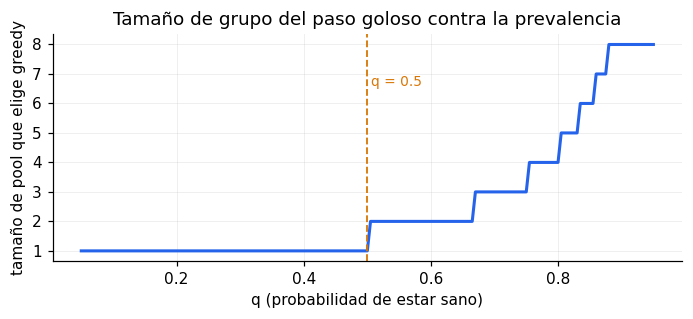

In [3]:
qs = np.linspace(0.05, 0.95, 181)
kopt = [tamano_pool_greedy(q) for q in qs]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(qs, kopt, color=AZUL, lw=2)
ax.axvline(0.5, color=AMBAR, ls='--', lw=1.2)
ax.text(0.505, 6.6, 'q = 0.5', color=AMBAR, fontsize=9)
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('tamaño de pool que elige greedy')
ax.set_yticks(range(1, 9))
ax.set_title('Tamaño de grupo del paso goloso contra la prevalencia')
plt.tight_layout(); plt.show()

**Lectura.** La medición global no discrimina en nuestro régimen: por debajo de
q = 0.5 devuelve m para todo grupo y toda prevalencia. La sesión del 18 de
agosto diagnostica la causa (greedy corre fuera del conjunto y desde cero) y
dicta la corrección de §2.

**Para discutir.** ¿Queda algún uso legítimo de la medición global, por ejemplo
como cota superior burda del costo, o se retira del todo?

## 2. La medición nueva: greedy local y posterior a la prueba (B-M6)

La receta de la sesión [15:44–16:34]: fijar T, aplicar la prueba, **simular el
conteo**, y correr greedy **dentro de T** condicionado a lo observado; el costo
es cuántas subpruebas usa, promediado sobre el conteo.

Micro-caso a mano, T de dos personas: si el conteo es 1, greedy prueba a la
primera; la mitad de las veces la acredita y termina (1 subprueba), la otra
mitad deduce al sano pero aún debe acreditarlo (2 subpruebas). Con conteos 0 y
2 no hay nada que hacer. C(T) = 2q(1−q) × 1.5 = 3q(1−q).

**Definición.** C(T) = número esperado de subpruebas que el greedy restringido
a T necesita, **después** de la prueba de T, para dejar a cada miembro
acreditado o resuelto, promediando sobre los conteos posibles de T; el total
con la prueba de T incluida es 1 + C(T). Es la tercera coordenada junto a las
dos ya definidas: S0(T) = P(pool limpio) × u(T) puntúa el cobro inmediato,
V(T) (presupuesto mágico) = suma de P(sano) × u puntúa la promesa, y C(T) mide
cuántas pruebas cuesta convertir esa promesa en certificados.

**Afirmación.** Medido así, el costo deja de ser plano: depende de q y de m, y
discrimina precisamente en el régimen q < 0.5 donde la medición global devolvía
siempre m.

In [4]:
def estados_prior(m, q):
    '''Los 2^m estados de T (1 = infectado) con su peso prior.'''
    out = []
    for z in itertools.product((0, 1), repeat=m):
        w = 1.0
        for b in z:
            w *= (1.0 - q) if b else q
        out.append((z, w))
    return out

def subpruebas_greedy_local(z, q, u=1.0):
    '''Subpruebas que greedy usa dentro de T tras la prueba global, estado real z.

    La global revela el conteo de infectados r = sum(z); si r = 0 acredita a todos.
    Despues, greedy elige el subpool de pendientes que maximiza
    S0 = P(todo sano | historia) * tamano (empate: el mas chico, primero en orden
    lexicografico), observa el conteo del subpool, acredita si r = 0,
    y repite hasta que nadie quede pendiente. Hard clearing: la deduccion informa
    pero solo una prueba limpia (conteo 0) acredita.
    '''
    m, r_global = len(z), sum(z)
    if r_global == m or r_global == 0:
        return 0
    belief = [(s, w) for s, w in estados_prior(m, q) if sum(s) == r_global]
    acreditados, n_sub = set(), 0
    while True:
        tot = sum(w for _, w in belief)
        p_sano = [sum(w for s, w in belief if not s[i]) / tot for i in range(m)]
        pend = [i for i in range(m) if i not in acreditados and p_sano[i] > 1e-12]
        if not pend:
            return n_sub
        mejor, mejor_s0 = None, -1.0
        for k in range(1, len(pend) + 1):
            for T in combinations(pend, k):
                p_all = sum(w for s, w in belief if all(not s[i] for i in T)) / tot
                s0 = p_all * k * u
                if s0 > mejor_s0 + 1e-12:
                    mejor, mejor_s0 = T, s0
        r = sum(z[i] for i in mejor)
        n_sub += 1
        belief = [(s, w) for s, w in belief if sum(s[i] for i in mejor) == r]
        if r == 0:
            acreditados.update(mejor)

def costo_local_exacto(m, q):
    '''C(T) exacto por enumeracion: esperanza de subpruebas sobre los 2^m estados.'''
    return sum(w * subpruebas_greedy_local(z, q) for z, w in estados_prior(m, q))

# Autoverificacion 1: la forma cerrada del micro-caso m=2.
for q in (0.15, 0.30, 0.45, 0.70):
    assert abs(costo_local_exacto(2, q) - 3 * q * (1 - q)) < 1e-12
print('OK: C(T) exacto coincide con la forma cerrada 3q(1-q) en m=2')

# Autoverificacion 2: Monte Carlo sembrado contra la enumeracion exacta.
from augmented.provenance import seeded_rng
rng = seeded_rng(20260821)
m_chk, q_chk, n_sim = 4, 0.30, 4000
muestras = [subpruebas_greedy_local(tuple(int(rng.random() >= q_chk) for _ in range(m_chk)), q_chk)
            for _ in range(n_sim)]
mc, se = np.mean(muestras), np.std(muestras, ddof=1) / np.sqrt(n_sim)
exacto = costo_local_exacto(m_chk, q_chk)
assert abs(mc - exacto) < 4 * se, (mc, exacto, se)
print(f'OK: Monte Carlo {mc:.3f} +- {se:.3f} coincide con el exacto {exacto:.3f}')

OK: C(T) exacto coincide con la forma cerrada 3q(1-q) en m=2


OK: Monte Carlo 2.053 +- 0.024 coincide con el exacto 2.094


In [5]:
filas = []
for q in (0.15, 0.30, 0.45):
    for m in (2, 3, 4, 5):
        c = costo_local_exacto(m, q)
        filas.append({'q': q, 'personas': m,
                      'subpruebas tras la global': c,
                      'total con la global': 1 + c,
                      'costo global viejo': float(m)})
nuevo = pd.DataFrame(filas)
print(nuevo.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

     q  personas  subpruebas tras la global  total con la global  costo global viejo
0.1500         2                     0.3825               1.3825              2.0000
0.1500         3                     0.7841               1.7841              3.0000
0.1500         4                     1.2645               2.2645              4.0000
0.1500         5                     1.8207               2.8207              5.0000
0.3000         2                     0.6300               1.6300              2.0000
0.3000         3                     1.3230               2.3230              3.0000
0.3000         4                     2.0937               3.0937              4.0000
0.3000         5                     2.9232               3.9232              5.0000
0.4500         2                     0.7425               1.7425              2.0000
0.4500         3                     1.5964               2.5964              3.0000
0.4500         4                     2.5140               3.5140 

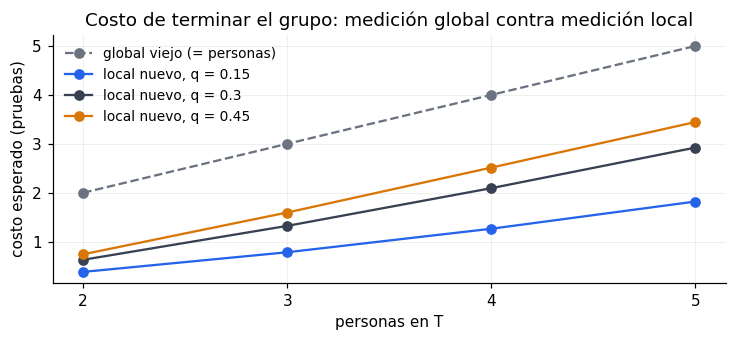

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 3.2))
ms = [2, 3, 4, 5]
ax.plot(ms, ms, color=GRIS, ls='--', marker='o', label='global viejo (= personas)')
for q, c in zip((0.15, 0.30, 0.45), (AZUL, TINTA, AMBAR)):
    sub = nuevo[nuevo.q == q]
    ax.plot(sub.personas, sub['subpruebas tras la global'], marker='o', color=c,
            label=f'local nuevo, q = {q}')
ax.set_xlabel('personas en T'); ax.set_ylabel('costo esperado (pruebas)')
ax.set_xticks(ms); ax.legend(frameon=False, fontsize=9)
ax.set_title('Costo de terminar el grupo: medición global contra medición local')
plt.tight_layout(); plt.show()

**Lectura.** El costo local separa lo que la medición global aplastaba: crece
con el grupo pero por debajo de m, y distingue las prevalencias entre sí. El
conteo de la prueba global ya hace trabajo (los casos extremos terminan solos),
y eso es exactamente lo que la medición global no veía.

**Para discutir.** La pregunta (16) del plan: ¿greedy local debe quedarse en T,
o puede tocar átomos abiertos fuera de T? Aquí se mide T solo; §5 y §8 traen
los datos de la variante como flag del barrido.

## 3. La preocupación q = 0.7, bajo el costo local

En el notebook 25 §9 quedó la duda: con q = 0.7 el grupo **sí** conviene, pero
una regla de costo podría rechazarlo. Bajo la medición local la duda se vuelve
un número: cuánto cuesta de verdad terminar el grupo, y si cabe en el
presupuesto.

**Afirmación.** Con q = 0.7 el costo local total del grupo supera 1, así que la
tijera C ≤ b filtra grupos con ventaja positiva justo cuando el presupuesto es
apenas suficiente — la preocupación era correcta y ahora está cuantificada.

In [7]:
from augmented.laminar_benchmarks import ExactPolicyEvaluator

def valor_realizable(m, b, q, u=1.0):
    '''Optimo exacto extraible de una subpoblacion fresca de m personas con b pruebas.'''
    if m == 0 or b == 0:
        return 0.0
    ev = ExactPolicyEvaluator([1 - q] * m, [u] * m, b, m)
    return ev.optimal_value()

Q7 = 0.7
costo7 = {m: costo_local_exacto(m, Q7) for m in (2, 3, 4)}
comp = []
for m in (2, 3, 4):
    for b in (1, 2, 3):
        v_grupo = valor_realizable(m, b, Q7)
        v_single = min(b, m) * Q7
        comp.append({'personas': m, 'presupuesto': b,
                     'ventaja del grupo': v_grupo - v_single,
                     'costo local total': 1 + costo7[m],
                     'cabe (tijera)': 1 + costo7[m] <= b})
cq = pd.DataFrame(comp)
print(cq.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion: el valor realizable es monotono en el presupuesto,
# y con q>0.5 el paso goloso si agrupa.
for m in (2, 3, 4):
    vs = [valor_realizable(m, b, Q7) for b in (1, 2, 3)]
    assert vs[0] <= vs[1] <= vs[2] + 1e-12
assert tamano_pool_greedy(Q7) > 1
print('\nOK: realizable monotono en b, y greedy agrupa con q=0.7')

 personas  presupuesto  ventaja del grupo  costo local total  cabe (tijera)
        2            1             0.2800             1.6300          False
        2            2             0.0000             1.6300           True
        2            3             0.0000             1.6300           True
        3            1             0.3290             2.4070          False
        3            2             0.2800             2.4070          False
        3            3             0.0000             2.4070           True
        4            1             0.3290             3.2617          False
        4            2             0.5600             3.2617          False
        4            3             0.4858             3.2617          False

OK: realizable monotono en b, y greedy agrupa con q=0.7


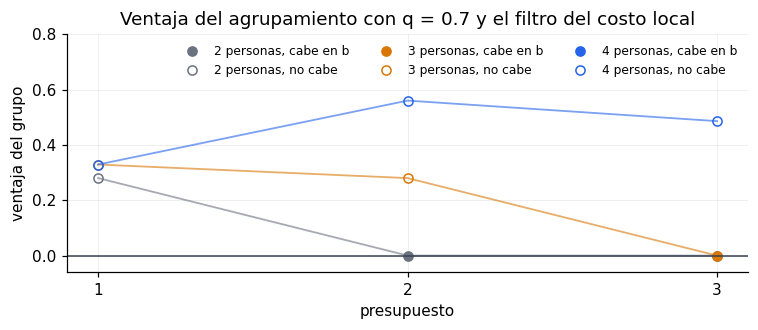

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 3.1))
for m, c in zip((2, 3, 4), (GRIS, AMBAR, AZUL)):
    sub = cq[cq.personas == m]
    dentro = sub[sub['cabe (tijera)']]
    fuera = sub[~sub['cabe (tijera)']]
    ax.plot(sub.presupuesto, sub['ventaja del grupo'], color=c, lw=1.2, alpha=0.6)
    ax.plot(dentro.presupuesto, dentro['ventaja del grupo'], 'o', color=c,
            label=f'{m} personas, cabe en b')
    ax.plot(fuera.presupuesto, fuera['ventaja del grupo'], 'o', color=c,
            mfc='none', label=f'{m} personas, no cabe')
ax.axhline(0, color=TINTA, lw=1)
ax.set_ylim(-0.06, 0.80)
ax.set_xlabel('presupuesto'); ax.set_ylabel('ventaja del grupo')
ax.set_xticks([1, 2, 3]); ax.legend(frameon=False, fontsize=8, ncol=3)
ax.set_title('Ventaja del agrupamiento con q = 0.7 y el filtro del costo local')
plt.tight_layout(); plt.show()

**Lectura.** Los marcadores rellenos son grupos cuyo costo local total cabe en
el presupuesto; los huecos, los que no. La tijera no prohíbe agrupar con
q = 0.7: prohíbe agrupar cuando no alcanza para terminar, que era la distinción
que la duda de la sesión pedía.

**Para discutir.** La pregunta (11) sigue viva: ¿la tijera debe usar la
esperanza del costo o un cuantil? Con presupuestos chicos la cola importa más
que la media.

## 4. El contraejemplo de no-reentrada, con artefacto (B-M16)

El estado de la sesión: un par AB ya probado con conteo 1 — hay un sano seguro,
la utilidad viva es 1, nadie está acreditado. Tres opciones sobre la mesa:
reentrar con A individual, abrir el par virgen CD, o retestear AB idéntico. El
score de presupuesto mágico (utilidad extraíble si las pruebas fueran gratis)
las puntúa 0.5, 0.6 y 1.0.

Nota de instancia: los números dictados en sesión cuadran con probabilidad de
estar **sano** 0.3 por persona (el acta dice "probabilidad de actividad 0.3";
con esa otra lectura el par virgen valdría 1.4 y el orden dictado no se
reproduce). El artefacto fija q = 0.3 de sano y lo deja registrado.

**Afirmación.** Con n = 4, q = 0.3 y utilidad uniforme, el score mágico ordena
retest AB (1.0) > par virgen CD (0.6) > individual A (0.5): la única acción que
cobra la utilidad viva queda al final, y el argmax se atasca retesteando el par
idéntico sin cobrar nunca.

In [9]:
# Numeros exactos por enumeracion, n = 4, aritmetica de fracciones.
Q = Fraction(3, 10)          # probabilidad de estar sano
NOMBRES = ['A', 'B', 'C', 'D']

def posterior_exacto(historia):
    '''Estados de (A,B,C,D) consistentes con la historia, con peso exacto.

    historia: lista de (pool, conteo de infectados observado); pool = tupla de indices.
    '''
    out = []
    for z in itertools.product((0, 1), repeat=4):
        if any(sum(z[i] for i in pool) != r for pool, r in historia):
            continue
        w = Fraction(1)
        for b in z:
            w *= 1 - Q if b else Q
        out.append((z, w))
    return out

def score_magico(pool, historia, acreditados=frozenset()):
    '''Utilidad extraible del pool si las pruebas fueran gratis: suma de
    P(sano | historia) sobre los miembros no acreditados.'''
    est = posterior_exacto(historia)
    tot = sum(w for _, w in est)
    return sum(sum(w for z, w in est if not z[i]) / tot
               for i in pool if i not in acreditados)

HIST0 = [((0, 1), 1)]        # AB probado, conteo de infectados = 1
s_A  = score_magico((0,), HIST0)
s_CD = score_magico((2, 3), HIST0)
s_AB = score_magico((0, 1), HIST0)
print(f'individual A : {s_A}  = {float(s_A)}')
print(f'par virgen CD: {s_CD} = {float(s_CD)}')
print(f'retest AB    : {s_AB}  = {float(s_AB)}')

assert s_A == Fraction(1, 2) and s_CD == Fraction(3, 5) and s_AB == 1
# P(A sano | conteo 1) = 1/2 independiente de la prevalencia.
for qq in (Fraction(1,10), Fraction(3,10), Fraction(7,10), Fraction(9,10)):
    est = [(z, ((1-qq) if z[0] else qq) * ((1-qq) if z[1] else qq))
           for z in itertools.product((0,1), repeat=2) if sum(z) == 1]
    tot = sum(w for _, w in est)
    assert sum(w for z, w in est if not z[0]) / tot == Fraction(1, 2)
print('\nOK: scores exactos 1/2, 3/5, 1 — y P(A sano | conteo 1) = 1/2 para toda q')

print('\nPosterior exacto tras AB con conteo 1 (8 estados):')
for z, w in posterior_exacto(HIST0):
    print('  ' + ''.join(f'{n}={"infectado" if b else "sano"} '
                         for n, b in zip(NOMBRES, z)) + f' peso {w}')

individual A : 1/2  = 0.5
par virgen CD: 3/5 = 0.6
retest AB    : 1  = 1.0

OK: scores exactos 1/2, 3/5, 1 — y P(A sano | conteo 1) = 1/2 para toda q

Posterior exacto tras AB con conteo 1 (8 estados):
  A=sano B=infectado C=sano D=sano  peso 189/10000
  A=sano B=infectado C=sano D=infectado  peso 441/10000
  A=sano B=infectado C=infectado D=sano  peso 441/10000
  A=sano B=infectado C=infectado D=infectado  peso 1029/10000
  A=infectado B=sano C=sano D=sano  peso 189/10000
  A=infectado B=sano C=sano D=infectado  peso 441/10000
  A=infectado B=sano C=infectado D=sano  peso 441/10000
  A=infectado B=sano C=infectado D=infectado  peso 1029/10000


In [10]:
# La trayectoria: seguir el argmax del score magico, con semilla.
from augmented.provenance import seeded_rng, write_canonical_csv

MENU = [(0,), (1,), (0, 1), (2,), (3,), (2, 3)]   # laminar: dentro de AB o virgen
SEED, N_SIM, HORIZONTE = 20260821, 2000, 6

def simula(primera, rng):
    '''Cobrada acumulada por prueba, forzando la primera accion y siguiendo
    despues el argmax puro del score magico (retest permitido).'''
    z = (1, 0) if rng.random() < 0.5 else (0, 1)          # conteo 1 en AB
    z = z + tuple(int(rng.random() >= float(Q)) for _ in range(2))
    historia, acred = list(HIST0), set()
    cobrada, curva = 0.0, []
    for t in range(HORIZONTE):
        if t == 0:
            pool = primera
        else:
            scores = [(score_magico(p, historia, frozenset(acred)), -len(p), p)
                      for p in MENU]
            s, _, pool = max(scores, key=lambda x: (x[0], x[1], -MENU.index(x[2])))
            if s == 0:
                curva.append(cobrada); continue
        r = sum(z[i] for i in pool)
        historia.append((tuple(pool), r))
        if r == 0:
            nuevos = [i for i in pool if i not in acred]
            cobrada += len(nuevos); acred.update(nuevos)
        curva.append(cobrada)
    return curva

rng = seeded_rng(SEED)
curvas = {}
for nombre, primera in [('individual A', (0,)), ('par virgen CD', (2, 3)),
                        ('retest AB', (0, 1))]:
    curvas[nombre] = np.mean([simula(primera, rng) for _ in range(N_SIM)], axis=0)

tray = pd.DataFrame(curvas, index=[f't={t}' for t in range(1, HORIZONTE + 1)]).T
print(tray.to_string(float_format=lambda x: f'{x:.3f}'))

# El argmax puro es el retest AB y nunca cobra; el orden del score es el inverso
# del orden de lo cobrado.
assert np.all(curvas['retest AB'] == 0.0)
assert curvas['individual A'][-1] > curvas['par virgen CD'][-1] > 0
print('\nOK: el retest identico cobra 0 siempre; el score ordena al reves de lo cobrado')

                t=1   t=2   t=3   t=4   t=5   t=6
individual A  0.498 1.082 1.169 1.169 1.169 1.169
par virgen CD 0.179 0.179 0.179 0.179 0.179 0.179
retest AB     0.000 0.000 0.000 0.000 0.000 0.000

OK: el retest identico cobra 0 siempre; el score ordena al reves de lo cobrado


In [11]:
filas = []
for nombre, s in [('individual A', s_A), ('par virgen CD', s_CD), ('retest AB', s_AB)]:
    filas.append({'opcion': nombre, 'score_exacto': float(s), 'score_fraccion': str(s),
                  'rango_por_score': sorted([s_A, s_CD, s_AB], reverse=True).index(s) + 1,
                  **{f'cobrada_esperada_t{t+1}': round(float(curvas[nombre][t]), 4)
                     for t in range(HORIZONTE)}})
ruta = write_canonical_csv(
    RES / 'no_reentrada_b_m16.csv', filas,
    generator='augmented/notebooks/build_costo_local_y_no_reentrada_notebook.py',
    seed=SEED,
    params={'n': 4, 'q_sano': '3/10', 'utilidad': 1, 'historia': 'AB conteo 1',
            'n_sim': N_SIM, 'horizonte': HORIZONTE,
            'politica': 'argmax del score de presupuesto magico, menu laminar'})
print('artefacto escrito:', ruta)
print(pd.read_csv(ruta).to_string(index=False))

artefacto escrito: /Users/hectorbecerrilvillamil/Desktop/GroupCounting/group-count-dynamic/results/no_reentrada_b_m16.csv
       opcion  score_exacto score_fraccion  rango_por_score  cobrada_esperada_t1  cobrada_esperada_t2  cobrada_esperada_t3  cobrada_esperada_t4  cobrada_esperada_t5  cobrada_esperada_t6
 individual A           0.5            1/2                3                0.498                1.082                1.169                1.169                1.169                1.169
par virgen CD           0.6            3/5                2                0.179                0.179                0.179                0.179                0.179                0.179
    retest AB           1.0              1                1                0.000                0.000                0.000                0.000                0.000                0.000


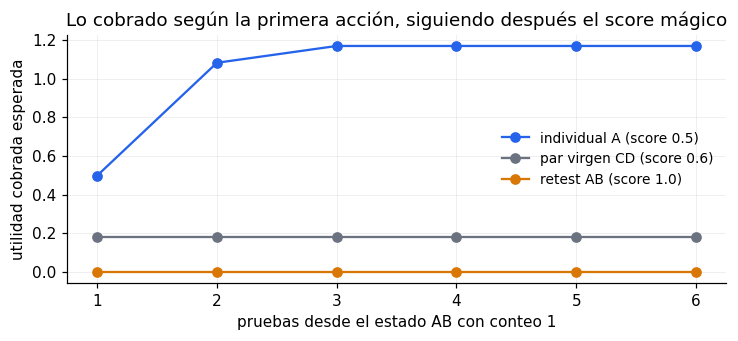

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 3.2))
ts = range(1, HORIZONTE + 1)
for nombre, c in [('individual A', AZUL), ('par virgen CD', GRIS), ('retest AB', AMBAR)]:
    ax.plot(ts, curvas[nombre], marker='o', color=c,
            label=f'{nombre} (score {float({"individual A": s_A, "par virgen CD": s_CD, "retest AB": s_AB}[nombre]):.1f})')
ax.set_xlabel('pruebas desde el estado AB con conteo 1')
ax.set_ylabel('utilidad cobrada esperada')
ax.set_xticks(list(ts)); ax.legend(frameon=False, fontsize=9)
ax.set_title('Lo cobrado según la primera acción, siguiendo después el score mágico')
plt.tight_layout(); plt.show()

**Lectura.** El score ordena exactamente al revés de lo que se cobra: su argmax
(retest AB, score 1.0) termina en cero para siempre, y la peor puntuada
(individual A, score 0.5) es la que cobra. No es un problema de empates ni de
ruido: es el score puntuando utilidad viva que ninguna de sus acciones cobra.

**Para discutir.** La pregunta (17): con el ancestro ABCD en el menú, el score
mágico le daría 1.6 y la no-reentrada se agrava. ¿La regla de subpruebas
laminares excluye también a los ancestros?

## 5. El alcance del costo local, con datos (pregunta 16)

Al medir C(T) hay una decisión pendiente: si greedy solo puede terminar T, o si
también puede tocar los **átomos abiertos** de pools ya probados — en el estado
de §4, las personas A y B del par con conteo 1. Sobre ese mismo estado se miden
las dos variantes para las cuatro acciones del menú.

Estatuto: dato para el barrido del sábado (flag), no selección de candidata.

**Afirmación.** El flag no es cosmético: con alcance T solo, el cociente
valor/costo total ya reordena bien el menú (la reentrada gana); con alcance
amplio, el costo castiga a la reentrada con el cierre del vecino y el retest
idéntico vuelve a ganar — la no-reentrada reaparece.

In [13]:
def subpruebas_con_alcance(z, historia0, T, bloques, amplio, q, u=1.0):
    '''Subpruebas tras la prueba de T, con el estado real z (1 = infectado).

    bloques: particion laminar de las personas en juego (un bloque por pool
    raiz); greedy solo propone subpools dentro de un bloque. Con amplio=False
    los pendientes se limitan a T; con amplio=True incluyen los atomos abiertos
    de los demas bloques. Mismas reglas que §2: S0 = P(todo sano)*tamano,
    empate al mas chico, acredita solo el conteo 0.
    '''
    n = len(z)
    historia = list(historia0) + [(tuple(T), sum(z[i] for i in T))]
    acred = set(T) if sum(z[i] for i in T) == 0 else set()
    n_sub = 0
    while True:
        belief = [(s, w) for s, w in estados_prior(n, q)
                  if all(sum(s[i] for i in p) == r for p, r in historia)]
        tot = sum(w for _, w in belief)
        p_sano = [sum(w for s, w in belief if not s[i]) / tot for i in range(n)]
        abiertos = {i for p, _ in historia0 for i in p}
        alcance = set(T) if not amplio else set(T) | abiertos
        pend = [i for i in range(n)
                if i in alcance and i not in acred and p_sano[i] > 1e-12]
        if not pend:
            return n_sub
        mejor, mejor_s0 = None, -1.0
        for blo in bloques:
            dentro = [i for i in pend if i in blo]
            for k in range(1, len(dentro) + 1):
                for P in combinations(dentro, k):
                    p_all = sum(w for s, w in belief if all(not s[i] for i in P)) / tot
                    s0 = p_all * k * u
                    if s0 > mejor_s0 + 1e-12:
                        mejor, mejor_s0 = P, s0
        r = sum(z[i] for i in mejor)
        n_sub += 1
        historia.append((tuple(mejor), r))
        if r == 0:
            acred.update(mejor)

def costo_con_alcance(historia0, T, bloques, amplio, q):
    '''Esperanza exacta de subpruebas, condicionada a la historia inicial.'''
    consist = [(z, w) for z, w in estados_prior(4, q)
               if all(sum(z[i] for i in p) == r for p, r in historia0)]
    tot = sum(w for _, w in consist)
    return sum(w * subpruebas_con_alcance(z, historia0, T, bloques, amplio, q)
               for z, w in consist) / tot

qf = float(Q)
BLOQUES = [(0, 1), (2, 3)]
ACCIONES = [('individual A', (0,), s_A), ('individual B', (1,), s_A),
            ('retest AB', (0, 1), s_AB), ('par virgen CD', (2, 3), s_CD)]
filas = []
for nombre, T, v in ACCIONES:
    for amplio in (False, True):
        c = costo_con_alcance(HIST0, T, BLOQUES, amplio, qf)
        filas.append({'accion': nombre, 'alcance': 'T y atomos abiertos' if amplio else 'T solo',
                      'V (score magico)': float(v), 'subpruebas tras T': c,
                      'C total': 1 + c, 'V/C (alfa=1)': float(v) / (1 + c)})
alc = pd.DataFrame(filas)
print(alc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion contra las cuentas a mano (q = 0.3, conteo 1 en AB):
# T solo: A y B terminan solos (0), el retest AB deja el par por cerrar (1.5),
# CD es el par fresco de §2 (3q(1-q) = 0.63). Amplio: A/B cargan el cierre del
# vecino (0.5), CD carga el par completo (0.63 + 1.5).
esperado = {('individual A', False): 0.0, ('individual B', False): 0.0,
            ('retest AB', False): 1.5, ('par virgen CD', False): 3*qf*(1-qf),
            ('individual A', True): 0.5, ('individual B', True): 0.5,
            ('retest AB', True): 1.5, ('par virgen CD', True): 3*qf*(1-qf) + 1.5}
for nombre, T, _ in ACCIONES:
    for amplio in (False, True):
        c = costo_con_alcance(HIST0, T, BLOQUES, amplio, qf)
        assert abs(c - esperado[(nombre, amplio)]) < 1e-12, (nombre, amplio, c)
print('\nOK: las ocho esperanzas coinciden con las cuentas a mano')

solo_s = alc[alc.alcance == 'T solo'].set_index('accion')['V/C (alfa=1)']
amp_s  = alc[alc.alcance != 'T solo'].set_index('accion')['V/C (alfa=1)']
assert solo_s.idxmax() == 'individual A' and amp_s.idxmax() == 'retest AB'
print(f'argmax con T solo: {solo_s.idxmax()} | con atomos abiertos: {amp_s.idxmax()}')

       accion             alcance  V (score magico)  subpruebas tras T  C total  V/C (alfa=1)
 individual A              T solo            0.5000             0.0000   1.0000        0.5000
 individual A T y atomos abiertos            0.5000             0.5000   1.5000        0.3333
 individual B              T solo            0.5000             0.0000   1.0000        0.5000
 individual B T y atomos abiertos            0.5000             0.5000   1.5000        0.3333
    retest AB              T solo            1.0000             1.5000   2.5000        0.4000
    retest AB T y atomos abiertos            1.0000             1.5000   2.5000        0.4000
par virgen CD              T solo            0.6000             0.6300   1.6300        0.3681
par virgen CD T y atomos abiertos            0.6000             2.1300   3.1300        0.1917

OK: las ocho esperanzas coinciden con las cuentas a mano
argmax con T solo: individual A | con atomos abiertos: retest AB


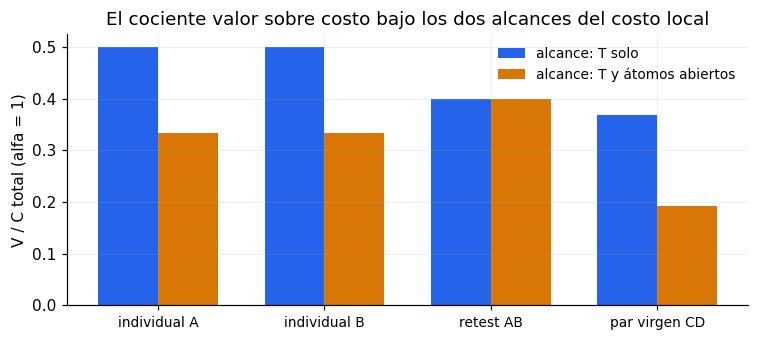

In [14]:
fig, ax = plt.subplots(figsize=(7.0, 3.2))
nombres = [a[0] for a in ACCIONES]
x = np.arange(len(nombres)); ancho = 0.36
solo = [alc[(alc.accion == n) & (alc.alcance == 'T solo')]['V/C (alfa=1)'].iloc[0] for n in nombres]
amp  = [alc[(alc.accion == n) & (alc.alcance != 'T solo')]['V/C (alfa=1)'].iloc[0] for n in nombres]
ax.bar(x - ancho/2, solo, ancho, color=AZUL, label='alcance: T solo')
ax.bar(x + ancho/2, amp, ancho, color=AMBAR, label='alcance: T y átomos abiertos')
ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylabel('V / C total (alfa = 1)')
ax.legend(frameon=False, fontsize=9)
ax.set_title('El cociente valor sobre costo bajo los dos alcances del costo local')
plt.tight_layout(); plt.show()

**Lectura.** Con T solo, el cociente con costo local ya deshace la no-reentrada
de §4: la reentrada individual gana el menú. Con alcance amplio el orden se
invierte — la reentrada carga el cierre del vecino, el retest puntúa la utilidad
viva completa, y el atasco reaparece. Por eso el barrido de §7–§8 corre con el
flag en las dos posiciones.

**Para discutir.** El cierre de los átomos abiertos existe en el estado elijas
lo que elijas: ¿pertenece al costo de la acción, o al valor del estado? Cobrarlo
por acción es lo que revive la no-reentrada.

## 6. Las reglas del barrido, ancladas al contraejemplo

Cada acción lleva los dos números de las secciones anteriores: V, la utilidad
extraíble (score de presupuesto mágico), y C, el costo local posterior a la
prueba (1 + subpruebas del greedy restringido). La familia del barrido es
V/C^α con la tijera C ≤ b; α = 0 es el extremo sin devaluación (solo la
tijera), que es el score del contraejemplo de no-reentrada.

**Afirmación.** La política queda declarada por completo: menú laminar de pools
de tamaño ≤ G sobre pendientes, score V/C^α con tijera, C medido con greedy
local (flag en T solo; §8 mueve el flag), y una regla de no-parálisis: si la
tijera vacía el menú, se toma el mejor cociente sin filtro — la política nunca
se detiene con presupuesto vivo y pendientes. En el estado del contraejemplo,
la devaluación deshace el atasco solo si es lo bastante fuerte: el argmax salta
del retest a la reentrada exactamente cuando α supera ln 2 / ln 2.5 ≈ 0.756.

In [15]:
def estados_prior_f(n, q):
    '''Como estados_prior de §2, con pesos float (el barrido no usa fracciones).'''
    return estados_prior(n, q)

def consistentes(estados, historia):
    return [(z, w) for z, w in estados
            if all(sum(z[i] for i in p) == r for p, r in historia)]

def laminar_ok(T, probados):
    '''T es anidado o disjunto con cada pool ya probado (§6.6 del plan).'''
    sT = set(T)
    for p in probados:
        sp = set(p)
        if not (sT <= sp or sp <= sT or not (sT & sp)):
            return False
    return True

class PoliticaBarrido:
    '''Politica golosa de un paso sobre el menu laminar.

    score: 'S0' (P(pool limpio) * tamano), o ('alfa', a) — V/C^a con la tijera
    C <= b; a = 0 es solo la tijera. C = 1 + subpruebas del greedy local
    posterior a la prueba (§2); con amplio=True el greedy local tambien puede
    tocar los atomos abiertos de pools ya probados (§5). Si la tijera vacia el
    menu, dispara la regla de no-paralisis: mejor cociente sin filtro. El valor
    de la politica es exacto: suma sobre los 2^n estados.
    '''

    def __init__(self, n, q, G, score, amplio=False):
        self.n, self.q, self.G = n, q, G
        self.score, self.amplio = score, amplio
        self.estados = estados_prior_f(n, q)
        self.memo_dec, self.memo_c = {}, {}
        self.fallbacks = 0        # decisiones donde la tijera vacio el menu

    def p_sano(self, belief):
        tot = sum(w for _, w in belief)
        return [sum(w for z, w in belief if not z[i]) / tot for i in range(self.n)]

    def subpruebas_en(self, z, historia, T, acred0):
        '''Subpruebas del greedy local tras probar T, con estado real z.'''
        historia = list(historia) + [(tuple(T), sum(z[i] for i in T))]
        acred = set(acred0) | (set(T) if sum(z[i] for i in T) == 0 else set())
        n_sub = 0
        while True:
            belief = consistentes(self.estados, historia)
            ps = self.p_sano(belief)
            abiertos = {i for p, _ in historia for i in p}
            ambito = set(T) | abiertos if self.amplio else set(T)
            pend = [i for i in ambito if i not in acred and ps[i] > 1e-12]
            if not pend:
                return n_sub
            probados = [p for p, _ in historia]
            tot = sum(w for _, w in belief)
            mejor, mejor_s0 = None, -1.0
            for k in range(1, len(pend) + 1):
                for P in combinations(pend, k):
                    if not laminar_ok(P, probados):
                        continue
                    p_all = sum(w for zz, w in belief if all(not zz[i] for i in P)) / tot
                    s0 = p_all * k
                    if s0 > mejor_s0 + 1e-12:
                        mejor, mejor_s0 = P, s0
            if mejor is None:
                return n_sub
            r = sum(z[i] for i in mejor)
            n_sub += 1
            historia.append((tuple(mejor), r))
            if r == 0:
                acred.update(mejor)

    def costo_local(self, historia, T, acred):
        key = (frozenset(historia), tuple(T), frozenset(acred))
        if key not in self.memo_c:
            belief = consistentes(self.estados, historia)
            tot = sum(w for _, w in belief)
            self.memo_c[key] = sum(
                w * self.subpruebas_en(z, historia, T, acred)
                for z, w in belief) / tot
        return self.memo_c[key]

    def decide(self, historia, acred, b):
        key = (frozenset(historia), frozenset(acred), b)
        if key in self.memo_dec:
            return self.memo_dec[key]
        belief = consistentes(self.estados, historia)
        ps = self.p_sano(belief)
        pend = [i for i in range(self.n) if i not in acred and ps[i] > 1e-12]
        probados = [p for p, _ in historia]
        tot = sum(w for _, w in belief)
        cands = [T for k in range(1, min(self.G, len(pend)) + 1)
                 for T in combinations(pend, k) if laminar_ok(T, probados)]

        def puntua(T, con_tijera):
            if self.score == 'S0':
                p_all = sum(w for z, w in belief if all(not z[i] for i in T)) / tot
                return p_all * len(T)
            a = self.score[1]
            c = 1 + self.costo_local(historia, T, acred)
            if con_tijera and c > b:
                return None                          # la tijera
            v = sum(ps[i] for i in T)
            return v / (c ** a) if a > 0 else v

        mejor, mejor_s = None, -1.0
        for T in cands:
            s = puntua(T, con_tijera=True)
            if s is not None and s > mejor_s + 1e-12:
                mejor, mejor_s = T, s
        if mejor is None and cands:
            # regla de no-paralisis: la tijera vacio el menu; mejor cociente sin filtro
            self.fallbacks += 1
            for T in cands:
                s = puntua(T, con_tijera=False)
                if s > mejor_s + 1e-12:
                    mejor, mejor_s = T, s
        self.memo_dec[key] = mejor
        return mejor

    def valor(self, B):
        '''Valor esperado exacto de la politica con presupuesto B.'''
        total = 0.0
        for z, w in self.estados:
            historia, acred, b, cobrada = [], set(), B, 0.0
            while b > 0:
                T = self.decide(tuple(historia), frozenset(acred), b)
                if T is None:
                    break
                r = sum(z[i] for i in T)
                historia.append((tuple(T), r))
                b -= 1
                if r == 0:
                    nuevos = [i for i in T if i not in acred]
                    cobrada += len(nuevos)
                    acred.update(nuevos)
            total += w * cobrada
        return total

# Ancla: el estado del contraejemplo de §4 (AB con conteo 1, q = 0.3).
HIST_ANCLA, Q0 = (((0, 1), 1),), 0.3
elige = {a: PoliticaBarrido(4, Q0, 2, ('alfa', a)).decide(HIST_ANCLA, frozenset(), 3)
         for a in (0.0, 0.5, 1.0, 1.5)}
assert elige[0.0] == (0, 1) and elige[0.5] == (0, 1), 'con devaluacion debil, atasco'
assert elige[1.0] == (0,) and elige[1.5] == (0,), 'con devaluacion fuerte, reentrada'
# Los C coinciden con el §5, y el umbral es exacto: el retest (V=1, C=2.5)
# empata a la reentrada (V=1/2, C=1) cuando 2.5^a = 2.
polb = PoliticaBarrido(4, Q0, 2, ('alfa', 1))
assert abs(1 + polb.costo_local(HIST_ANCLA, (0, 1), frozenset()) - 2.50) < 1e-12
assert abs(1 + polb.costo_local(HIST_ANCLA, (2, 3), frozenset()) - 1.63) < 1e-12
alfa_critico = math.log(2) / math.log(2.5)
print('eleccion por alfa:', {a: p for a, p in elige.items()})
print(f'OK: el atasco persiste hasta alfa* = ln2/ln2.5 = {alfa_critico:.4f}')
print('OK: los C totales reproducen el §5 (retest 2.50, par virgen 1.63)')

eleccion por alfa: {0.0: (0, 1), 0.5: (0, 1), 1.0: (0,), 1.5: (0,)}
OK: el atasco persiste hasta alfa* = ln2/ln2.5 = 0.7565
OK: los C totales reproducen el §5 (retest 2.50, par virgen 1.63)


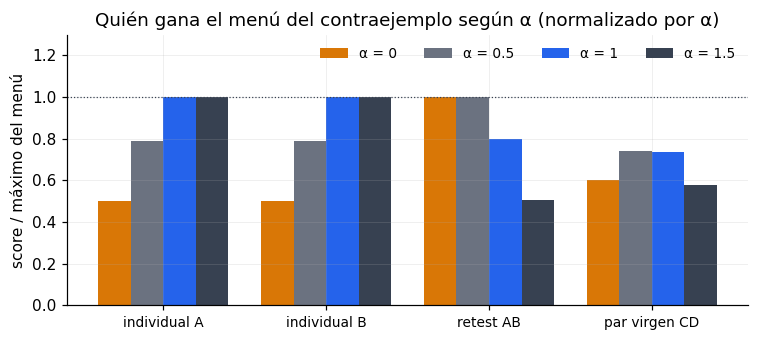

In [16]:
MENU_ANCLA = [('individual A', (0,)), ('individual B', (1,)),
              ('retest AB', (0, 1)), ('par virgen CD', (2, 3))]
ALFAS = [0.0, 0.5, 1.0, 1.5]
belief0 = consistentes(polb.estados, list(HIST_ANCLA))
ps0 = polb.p_sano(belief0)
scores_a = {}
for a in ALFAS:
    col = []
    for _, T in MENU_ANCLA:
        v = sum(ps0[i] for i in T)
        c = 1 + polb.costo_local(HIST_ANCLA, T, frozenset())
        col.append(v / (c ** a) if a > 0 else v)
    scores_a[a] = np.array(col) / max(col)    # normalizado: el argmax llega a 1

fig, ax = plt.subplots(figsize=(7.0, 3.2))
x = np.arange(len(MENU_ANCLA)); ancho = 0.2
for j, (a, c) in enumerate(zip(ALFAS, (AMBAR, GRIS, AZUL, TINTA))):
    ax.bar(x + (j - 1.5) * ancho, scores_a[a], ancho, color=c, label=f'α = {a:g}')
ax.axhline(1.0, color=TINTA, lw=0.8, ls=':')
ax.set_ylim(0, 1.30)
ax.set_xticks(x); ax.set_xticklabels([n for n, _ in MENU_ANCLA], fontsize=9)
ax.set_ylabel('score / máximo del menú')
ax.legend(frameon=False, fontsize=9, ncol=4)
ax.set_title('Quién gana el menú del contraejemplo según α (normalizado por α)')
plt.tight_layout(); plt.show()

**Lectura.** Con α = 0 y α = ½ el retest idéntico sigue ganando el menú: la
devaluación débil no basta. El argmax salta a la reentrada individual justo en
α* = ln 2 / ln 2.5 ≈ 0.756, así que de los tres α de la sesión solo 1 y 3/2
deshacen la no-reentrada en este estado. Es la tijera más la devaluación
fuerte, no cualquier cociente, lo que corrige el atasco — dato directo para la
congelación de α (pregunta 14).

**Para discutir.** La pregunta (14): si el α bueno depende del régimen, ¿se
congela un α global antes del atlas o un α por régimen declarado de antemano?

## 7. La corrida sobre la malla exacta

La malla: n ∈ {4, 5, 6}, B ∈ {1, 2, 3}, G ∈ {2, 3}, q ∈ {0.15, 0.30, 0.45,
0.70} — 72 instancias, prior homogéneo, u = 1. Por instancia corren S0 y la
familia α ∈ {0, ½, 1, 3/2}, y las referencias exactas V* (dinámico aumentado
irrestricto con tope G) y V*L (mejor biblioteca laminar fija).

**Afirmación.** Ningún α domina: hay instancias donde α = 3/2 gana a α = ½ y
viceversa, el ganador se mueve con el régimen, y la familia solo supera a S0 en
parte de la malla — el dato empírico de que el colapso 2D → 1D no tiene
respuesta canónica.

In [17]:
from augmented.laminar_benchmarks import dynamic_augmented_value, laminar_augmented_value

SCORES = [('S0', 'S0'), ('alfa=0', ('alfa', 0.0)), ('alfa=0.5', ('alfa', 0.5)),
          ('alfa=1', ('alfa', 1.0)), ('alfa=1.5', ('alfa', 1.5))]
t0 = time.time()
filas = []
for n in (4, 5, 6):
    for B in (1, 2, 3):
        for G in (2, 3):
            for q in (0.15, 0.30, 0.45, 0.70):
                p, u = [1 - q] * n, [1.0] * n
                v_star = dynamic_augmented_value(p, u, B, G)
                v_lam = laminar_augmented_value(p, u, B, G)
                for nombre, sc in SCORES:
                    v = PoliticaBarrido(n, q, G, sc).valor(B)
                    assert v <= v_star + 1e-9, (n, B, G, q, nombre, v, v_star)
                    filas.append({'n': n, 'B': B, 'G': G, 'q': q, 'score': nombre,
                                  'valor': v, 'v_star': v_star, 'v_star_laminar': v_lam,
                                  'ratio_vs_optimo': v / v_star})
barr = pd.DataFrame(filas)
print(f'{len(barr)} corridas exactas en {time.time() - t0:.0f}s; '
      'toda politica quedo por debajo de V* (verificado)')

piv = barr.pivot_table(index='q', columns='score', values='ratio_vs_optimo', aggfunc='mean')
piv = piv[[s for s, _ in SCORES]]
print('\nratio medio contra V* por regimen:\n')
print(piv.to_string(float_format=lambda x: f'{x:.4f}'))

# Ningun alfa domina: hay instancias en las que 3/2 gana a 1/2 y al reves.
ancha = barr.pivot_table(index=['n', 'B', 'G', 'q'], columns='score', values='valor')
assert (ancha['alfa=1.5'] > ancha['alfa=0.5'] + 1e-9).any()
assert (ancha['alfa=0.5'] > ancha['alfa=1.5'] + 1e-9).any()
gana_s0 = (ancha[['alfa=0.5', 'alfa=1', 'alfa=1.5']].max(axis=1) > ancha['S0'] + 1e-9)
print(f'\nOK: 3/2 y 1/2 se ganan mutuamente segun la instancia; '
      f'la familia supera a S0 en {gana_s0.sum()} de {len(ancha)} instancias')

ruta = write_canonical_csv(
    RES / 'barrido_alfa_diagnostico.csv', filas,
    generator='augmented/notebooks/build_costo_local_y_no_reentrada_notebook.py',
    seed=None,
    params={'malla': 'n 4-6, B 1-3, G 2-3, q {0.15,0.30,0.45,0.70}',
            'prior': 'homogeneo', 'u': 1, 'alcance': 'T solo',
            'metodo': 'exacto por enumeracion (sin Monte Carlo)',
            'estatuto': 'diagnostico 23.6; no seleccion de candidata'})
print('artefacto escrito:', ruta.name)

360 corridas exactas en 53s; toda politica quedo por debajo de V* (verificado)

ratio medio contra V* por regimen:

score     S0  alfa=0  alfa=0.5  alfa=1  alfa=1.5
q                                               
0.15  0.9431  0.9087    0.9087  0.9187    0.9187
0.30  0.9634  0.9038    0.9363  0.9420    0.9634
0.45  0.9684  0.9409    0.9409  0.9495    0.9684
0.70  0.9599  0.8136    0.8136  0.8117    0.7206

OK: 3/2 y 1/2 se ganan mutuamente segun la instancia; la familia supera a S0 en 7 de 72 instancias
artefacto escrito: barrido_alfa_diagnostico.csv


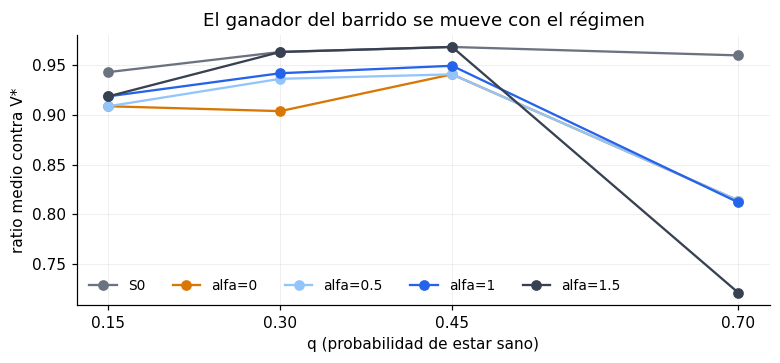

In [18]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
colores = {'S0': GRIS, 'alfa=0': AMBAR, 'alfa=0.5': '#93c5fd', 'alfa=1': AZUL,
           'alfa=1.5': TINTA}
for s, _ in SCORES:
    ax.plot(piv.index, piv[s], marker='o', color=colores[s], label=s)
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('ratio medio contra V*')
ax.set_xticks(piv.index.tolist())
ax.legend(frameon=False, fontsize=9, ncol=5)
ax.set_title('El ganador del barrido se mueve con el régimen')
plt.tight_layout(); plt.show()

**Lectura.** En prevalencia alta (q ≤ 0.45) castigar el costo ayuda: α = 3/2
empata o gana, y α chico paga pools cuya utilidad viva luego no cobra. En
q = 0.70 se invierte: α = 3/2 sobre-castiga y deja de agrupar. La familia
supera a S0 solo en parte de la malla — el premio del paso miope con costo es
real pero no uniforme, y no hay α canónico que quedarse.

**Para discutir.** Donde la familia no supera a S0, ¿el premio está en el paso
siguiente (lookahead, rollout) y no en el score de un paso? Es la misma
pregunta que dejó el §7 del notebook 25: el valor realizable exacto cuesta lo
mismo que resolver el problema.

## 8. El flag de alcance, dentro de la corrida

El §5 mostró que el alcance del costo (T solo contra T y átomos abiertos)
cambia el argmax en un estado fijo. Aquí se mueve el flag dentro de la corrida
completa: mismas instancias, misma familia, y el costo local puede o no tocar
los átomos que la propia política dejó abiertos.

**Afirmación.** El flag cambia el valor terminal en las dos direcciones según
la instancia y el α — no es una convención inocua, y el barrido del atlas debe
declararlo como dimensión.

In [19]:
INSTANCIAS = [(4, 3, 2, 0.30), (5, 3, 2, 0.30), (5, 3, 3, 0.70)]
filas = []
for n, B, G, q in INSTANCIAS:
    for a in (0.0, 0.5, 1.0, 1.5):
        p_solo = PoliticaBarrido(n, q, G, ('alfa', a), amplio=False)
        p_amp = PoliticaBarrido(n, q, G, ('alfa', a), amplio=True)
        v_solo, v_amp = p_solo.valor(B), p_amp.valor(B)
        filas.append({'n': n, 'B': B, 'G': G, 'q': q, 'alfa': a,
                      'T solo': v_solo, 'T y atomos abiertos': v_amp,
                      'diferencia': v_amp - v_solo,
                      'fallbacks (amplio)': p_amp.fallbacks})
flg = pd.DataFrame(filas)
print(flg.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# El flag mueve el valor en ambas direcciones, y con alcance amplio la tijera
# si llega a vaciar el menu (ahi dispara la regla de no-paralisis).
assert (flg.diferencia > 1e-9).any() and (flg.diferencia < -1e-9).any()
assert p_solo.fallbacks == 0 and (flg['fallbacks (amplio)'] > 0).any()
print('\nOK: el alcance amplio mejora en unas celdas y empeora en otras;')
print('OK: con T solo la tijera nunca vacia el menu, con alcance amplio si')

 n  B  G      q   alfa  T solo  T y atomos abiertos  diferencia  fallbacks (amplio)
 4  3  2 0.3000 0.0000  0.6918               0.7674      0.0756                   2
 4  3  2 0.3000 0.5000  0.8892               0.7674     -0.1218                   2
 4  3  2 0.3000 1.0000  0.8892               0.7674     -0.1218                   2
 4  3  2 0.3000 1.5000  0.9000               0.9000      0.0000                   0
 5  3  2 0.3000 0.0000  0.7927               0.8683      0.0756                   2
 5  3  2 0.3000 0.5000  0.9901               0.8683     -0.1218                   2
 5  3  2 0.3000 1.0000  0.9901               0.8683     -0.1218                   2
 5  3  2 0.3000 1.5000  0.9000               0.9000      0.0000                   0
 5  3  3 0.7000 0.0000  2.4569               1.6222     -0.8348                   5
 5  3  3 0.7000 0.5000  2.4569               1.6222     -0.8348                   5
 5  3  3 0.7000 1.0000  2.4569               1.6222     -0.8348             

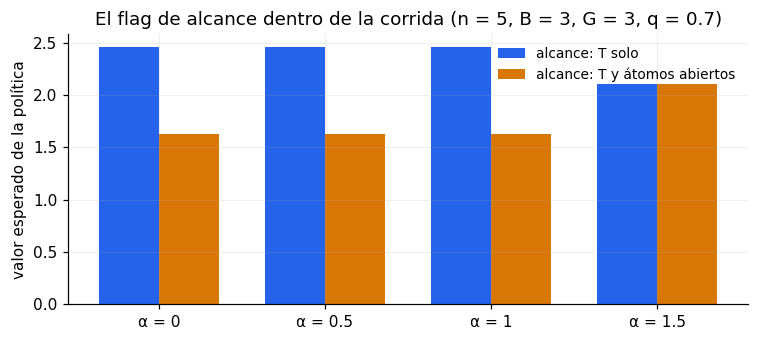

In [20]:
fig, ax = plt.subplots(figsize=(7.0, 3.2))
sub = flg[(flg.n == 5) & (flg.G == 3)]
x = np.arange(len(sub)); ancho = 0.36
ax.bar(x - ancho/2, sub['T solo'], ancho, color=AZUL, label='alcance: T solo')
ax.bar(x + ancho/2, sub['T y atomos abiertos'], ancho, color=AMBAR,
       label='alcance: T y átomos abiertos')
ax.set_xticks(x); ax.set_xticklabels([f'α = {a:g}' for a in sub.alfa])
ax.set_ylabel('valor esperado de la política')
ax.legend(frameon=False, fontsize=9)
ax.set_title('El flag de alcance dentro de la corrida (n = 5, B = 3, G = 3, q = 0.7)')
plt.tight_layout(); plt.show()

**Lectura.** El flag interactúa con α en las dos direcciones: en prevalencia
alta el alcance amplio rescata a α = 0 del atasco (+0.08, el retest deja de
puntuar gratis) pero empeora a α = ½ y 1; en q = 0.7 empeora a todos los α
chicos, porque el costo inflado con el vecindario hace que la tijera vacíe el
menú — ahí dispara la regla de no-parálisis, que puntúa sin filtro. El alcance
amplio no solo mueve el argmax: distorsiona la propia tijera. No se puede
congelar α sin declarar el flag.

**Para discutir.** La pregunta (16), ahora con valor terminal: si el cierre de
los átomos abiertos existe elijas lo que elijas, ¿debe entrar al costo de la
acción (alcance amplio) o al valor del estado (T solo más un término aparte)?

---
# PARTE II — La brecha de convención y el solver exacto

La sesión del 25 de agosto trajo el companion y dos cambios: la convención
normativa pasó a **posterior-zero** (la deducción acredita; G0, ratificado el
31-ago) y el encargo B-M17: implementar la ecuación de Bellman exacta. Esta
parte usa ese solver como testigo. Nota de traducción: el solver habla la
convención del companion (la prueba reporta el conteo de **infectados**); los
enunciados de abajo siguen hablando de sanos, como el resto del notebook.

## 9. El solver exacto, cotejado por segunda vía

El solver (recursión 5.5 del companion: estado = vírgenes + átomos residuales
+ presupuesto, memoizado, en fracciones) se validó contra los tests de
aceptación que A derivó a mano, y contra un resultado viejo: el óptimo del
caso de sesión del notebook 24.

**Afirmación.** En la instancia del contraejemplo (n = 4, q = 0.3, G = 2), el
solver reproduce exacto la spec de A bajo la variante estricta — óptimo 3/5
con B = 2, sin agrupar — y con B = 3 devuelve q(3q² − 3q + 4) = 1.011, el
óptimo del caso de sesión, por una vía independiente.

In [21]:
from augmented.bm17_toy_solver import SolverLaminar

Q_SANO = Fraction(3, 10)
p_inf = {i: 1 - Q_SANO for i in range(4)}
u_uno = {i: Fraction(1) for i in range(4)}
U4 = frozenset(range(4))

valores = {}
for conv in ('strict', 'posterior_zero'):
    for B_ in (2, 3):
        valores[(conv, B_)] = SolverLaminar(p_inf, u_uno, 2, conv).V(U4, (), B_)

# Spec de A (tests de aceptacion, 2026-08-20): optimo estricto 3/5, sin agrupar.
assert valores[('strict', 2)] == Fraction(3, 5)
sol_s = SolverLaminar(p_inf, u_uno, 2, 'strict')
assert len(sol_s.politica(U4, (), 2)[1]) == 1
# Consistencia con el notebook 24: q(3q^2 - 3q + 4) en q = 0.3.
q = Q_SANO
assert valores[('strict', 3)] == q * (3*q**2 - 3*q + 4) == Fraction(1011, 1000)
tabla = pd.DataFrame([{'convención': c, 'B': B_, 'óptimo laminar': float(v)}
                      for (c, B_), v in valores.items()])
print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nOK: spec de A reproducida y consistencia exacta con el notebook 24')

    convención  B  óptimo laminar
        strict  2          0.6000
        strict  3          1.0110
posterior_zero  2          0.7740
posterior_zero  3          1.0740

OK: spec de A reproducida y consistencia exacta con el notebook 24


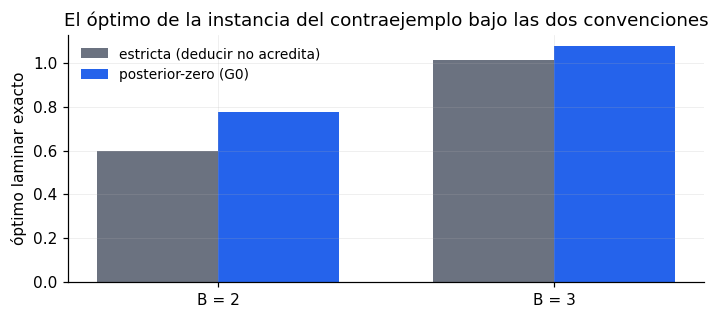

In [22]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(2); ancho = 0.36
v_s = [float(valores[('strict', B_)]) for B_ in (2, 3)]
v_z = [float(valores[('posterior_zero', B_)]) for B_ in (2, 3)]
ax.bar(x - ancho/2, v_s, ancho, color=GRIS, label='estricta (deducir no acredita)')
ax.bar(x + ancho/2, v_z, ancho, color=AZUL, label='posterior-zero (G0)')
ax.set_xticks(x); ax.set_xticklabels(['B = 2', 'B = 3'])
ax.set_ylabel('óptimo laminar exacto')
ax.legend(frameon=False, fontsize=9)
ax.set_title('El óptimo de la instancia del contraejemplo bajo las dos convenciones')
plt.tight_layout(); plt.show()

**Lectura.** El solver coincide dígito por dígito con las dos referencias
independientes que existían (la enumeración a mano de A y el caso del
notebook 24). Con eso queda habilitado como juez para todo lo que sigue.

**Para discutir.** La validación de dos vías contra el enumerador pathwise
(n ≤ 5) está agendada; ¿algún otro ancla viejo vale la pena cotejar?

## 10. La brecha de convención cambia la política

La cuenta de la ratificación de G0, ahora por máquina. En el estado del
contraejemplo, la reentrada con {a} vale 0.5 bajo estricta (la rama donde
deduces a la sana no cobra) y 1.0 bajo posterior-zero (las dos ramas cobran).
Esa diferencia se propaga hasta la acción inicial.

**Afirmación.** Con B = 2 la convención no solo mueve el valor: cambia la
primera acción óptima — estricta abre un singleton (3/5); posterior-zero abre
el par (387/500 = 0.774), porque el par con conteo 1 más una prueba cobra 1
seguro.

In [23]:
atomo_ab = (((0, 1), 1),)
reent = {}
for conv in ('strict', 'posterior_zero'):
    sol = SolverLaminar(p_inf, u_uno, 2, conv)
    reent[conv] = sol.valor_forzando_primera(
        frozenset((2, 3)), atomo_ab, 1, ('ref', ((0, 1), 1), (0,)))
assert reent['strict'] == Fraction(1, 2) and reent['posterior_zero'] == 1
print(f"reentrada con {{a}}: estricta {reent['strict']}, "
      f"posterior-zero {reent['posterior_zero']}")

primeras = {}
for conv in ('strict', 'posterior_zero'):
    sol = SolverLaminar(p_inf, u_uno, 2, conv)
    primeras[conv] = {
        'singleton': sol.valor_forzando_primera(U4, (), 2, ('open', (0,))),
        'par': sol.valor_forzando_primera(U4, (), 2, ('open', (0, 1)))}
assert primeras['strict']['singleton'] == Fraction(3, 5) \
    and primeras['strict']['singleton'] > primeras['strict']['par']
assert primeras['posterior_zero']['par'] == Fraction(387, 500) \
    and primeras['posterior_zero']['par'] > primeras['posterior_zero']['singleton']
print('\nvalor de cada primera accion (B = 2):')
for conv, d in primeras.items():
    print(f"  {conv:14s}: singleton {float(d['singleton']):.3f}, "
          f"par {float(d['par']):.3f}")
print('\nOK: el argmax cambia de singleton (estricta) a par (posterior-zero)')

reentrada con {a}: estricta 1/2, posterior-zero 1

valor de cada primera accion (B = 2):
  strict        : singleton 0.600, par 0.564
  posterior_zero: singleton 0.600, par 0.774

OK: el argmax cambia de singleton (estricta) a par (posterior-zero)


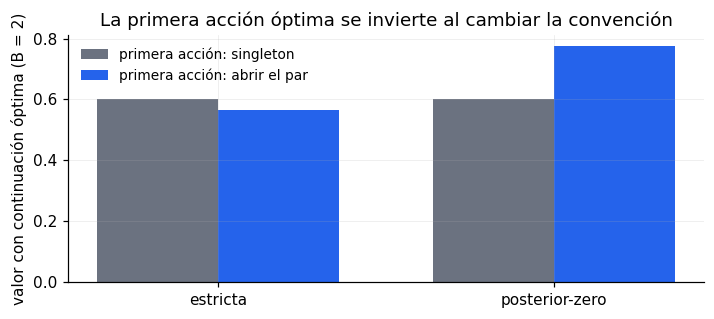

In [24]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(2); ancho = 0.36
sing = [float(primeras[c]['singleton']) for c in ('strict', 'posterior_zero')]
par = [float(primeras[c]['par']) for c in ('strict', 'posterior_zero')]
ax.bar(x - ancho/2, sing, ancho, color=GRIS, label='primera acción: singleton')
ax.bar(x + ancho/2, par, ancho, color=AZUL, label='primera acción: abrir el par')
ax.set_xticks(x); ax.set_xticklabels(['estricta', 'posterior-zero'])
ax.set_ylabel('valor con continuación óptima (B = 2)')
ax.legend(frameon=False, fontsize=9)
ax.set_title('La primera acción óptima se invierte al cambiar la convención')
plt.tight_layout(); plt.show()

**Lectura.** La deducción gratuita vuelve rentable el agrupamiento donde antes
no lo era: es la evidencia computacional de la Proposición de brecha de
convención (los números duales de B-M18). Nada de la parte I queda invalidado
— queda etiquetado como la variante estricta.

**Para discutir.** ¿La Proposición se enuncia sobre esta instancia mínima o
sobre la familia (la brecha como función de q y B)?

## 11. El empate exacto en B = 3: la brecha no es monótona

Si la ventaja de agrupar viniera de la convención sola, crecería con el
presupuesto. No: el motor es la maniobra "par con conteo 1 + una prueba
= cobro seguro", que con B = 2 exige empezar por el par. Con B = 3 sobra
presupuesto para hacerla después de cualquier inicio.

**Afirmación.** Bajo posterior-zero con B = 3, el singleton y el par empatan
exactos como primera acción (537/500 por ambos caminos): la ventaja estricta
del par en B = 2 (+0.174) se disuelve cuando el presupuesto deja de ser
escaso.

In [25]:
ventaja = {}
for B_ in (2, 3):
    sol = SolverLaminar(p_inf, u_uno, 2, 'posterior_zero')
    v_par = sol.valor_forzando_primera(U4, (), B_, ('open', (0, 1)))
    v_sing = sol.valor_forzando_primera(U4, (), B_, ('open', (0,)))
    ventaja[B_] = (v_par, v_sing, v_par - v_sing)
    print(f'B = {B_}: par {v_par} ({float(v_par):.4f}), '
          f'singleton {v_sing} ({float(v_sing):.4f}), '
          f'ventaja del par {float(v_par - v_sing):+.4f}')
assert ventaja[2][2] > 0
assert ventaja[3][0] == ventaja[3][1] == Fraction(537, 500)
print('\nOK: ventaja estricta en B = 2 y empate EXACTO en B = 3 (fracciones)')

B = 2: par 387/500 (0.7740), singleton 3/5 (0.6000), ventaja del par +0.1740
B = 3: par 537/500 (1.0740), singleton 537/500 (1.0740), ventaja del par +0.0000

OK: ventaja estricta en B = 2 y empate EXACTO en B = 3 (fracciones)


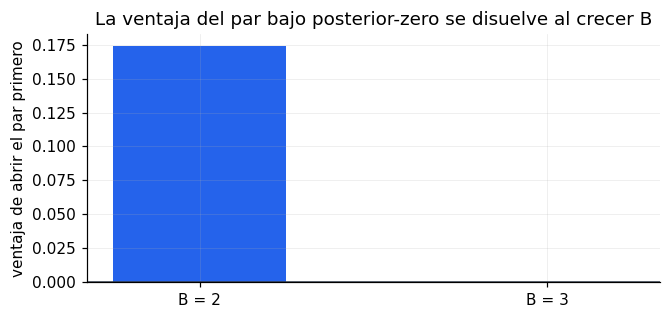

In [26]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
bs = [2, 3]
ax.bar(bs, [float(ventaja[b][2]) for b in bs], 0.5, color=AZUL)
ax.axhline(0, color=TINTA, lw=1)
ax.set_xticks(bs); ax.set_xticklabels(['B = 2', 'B = 3'])
ax.set_ylabel('ventaja de abrir el par primero')
ax.set_title('La ventaja del par bajo posterior-zero se disuelve al crecer B')
plt.tight_layout(); plt.show()

**Lectura.** La brecha de convención es un fenómeno de **presupuesto escaso**:
la deducción vale oro cuando no alcanza para la prueba acreditadora y se
diluye cuando sobra. El enunciado de la Proposición debe condicionar en esa
escasez.

**Para discutir.** ¿Cuál es la forma correcta de la condición de escasez —
B contra el costo de la maniobra, o algo más fino?

## 12. La misión V̂: un score de fórmula cerrada al 99.9% del óptimo

**Estatuto: descubierto por búsqueda automática, diagnóstico (§25, candidata
E de §14.8), pendiente de G4a/G4b.** La misión del harness autoresearch buscó
una fórmula score(acción) cuya política golosa se acercara al óptimo exacto,
con el solver de §9 como juez. El candidato final (C3) tiene tres sumandos
legibles: cobro inmediato con el crédito del complemento deducido (el M_h del
companion bajo G0), promesa ponderada por factibilidad presupuestal (la tijera
suave), y el costo de oportunidad de los vírgenes no consumidos.

**Afirmación.** C3 alcanza media 0.9993 y peor caso 0.9647 contra el óptimo
exacto en las 48 instancias de entrenamiento, y 1.0 exacto en las 4 de
held-out (n = 6) — cerrando la disyuntiva de las semillas, que tenían buena
media o buen peor caso pero no ambos.

In [27]:
from augmented.evolucion_scores import evalua, TRAIN, HELDOUT, SEMILLAS

C3 = '''
def score(ctx):
    u_S = ctx['u_S']
    tam = ctx['tam']
    imm = ctx['p_limpio'] * u_S
    if ctx['tipo'] == 'ref':
        at, r = ctx['atomo_tam'], ctx['atomo_r']
        resto = at - tam
        if resto > 0 and 0 < r <= tam:
            imm += (math.comb(tam, r) / math.comb(at, r)) * (u_S / tam) * resto
    promesa = ctx['v_magico'] - ctx['p_limpio'] * u_S
    total = imm
    if promesa > 0:
        c_extra = math.ceil(math.log2(tam)) if tam > 1 else 1
        total += min(1.0, (ctx['b'] - 1) / c_extra) * promesa
    virg = ctx['virgenes'] - (tam if ctx['tipo'] == 'open' else 0)
    if virg > 0 and ctx['b'] > 1:
        total += min(ctx['b'] - 1, virg) * (ctx['e_sanos'] / tam) * (u_S / tam)
    return total
'''

filas = []
for nombre, codigo in list(SEMILLAS.items()) + [('C3 (keep candidato)', C3)]:
    mt, pt, _ = evalua(codigo, TRAIN)
    mh, ph, _ = evalua(codigo, HELDOUT)
    filas.append({'candidato': nombre, 'media train': mt, 'peor train': pt,
                  'media held-out': mh, 'peor held-out': ph})
mision = pd.DataFrame(filas)
print(mision.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion contra el scoreboard versionado de la mision.
board = pd.read_csv(RAIZ / 'results' / 'vhat_mission_scoreboard.tsv', sep='\t')
c3_board = board[board.description.str.contains('KEEP-CANDIDATO FINAL')].iloc[0]
c3_vivo = mision.iloc[-1]
assert abs(c3_vivo['media train'] - c3_board.media_train) < 1e-6
assert abs(c3_vivo['peor train'] - c3_board.peor_train) < 1e-6
assert c3_vivo['media held-out'] == 1.0 and c3_vivo['peor held-out'] == 1.0
print('\nOK: C3 re-evaluado en vivo coincide con el scoreboard versionado')

          candidato  media train  peor train  media held-out  peor held-out
       s0_inmediato       0.8492      0.6877          0.7924         0.6588
 presupuesto_magico       0.8780      0.4651          0.8005         0.4800
    densidad_magica       0.8057      0.6467          0.7179         0.6588
valor_por_biseccion       0.8057      0.6467          0.7179         0.6588
C3 (keep candidato)       0.9993      0.9647          1.0000         1.0000

OK: C3 re-evaluado en vivo coincide con el scoreboard versionado


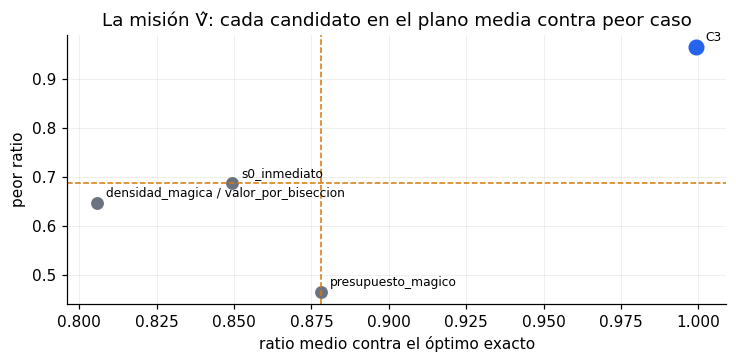

In [28]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
puntos = {}
for _, f in mision.iterrows():
    xy = (round(f['media train'], 6), round(f['peor train'], 6))
    puntos.setdefault(xy, []).append(f.candidato.split(' ')[0])
for (mx, px), nombres in puntos.items():
    es_c3 = any('C3' in n for n in nombres)
    ax.scatter(mx, px, s=90 if es_c3 else 55,
               color=AZUL if es_c3 else GRIS, zorder=3 if es_c3 else 2)
    ax.annotate(' / '.join(nombres), (mx, px),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axvline(0.8780, color=AMBAR, ls='--', lw=1)
ax.axhline(0.6877, color=AMBAR, ls='--', lw=1)
ax.set_xlabel('ratio medio contra el óptimo exacto')
ax.set_ylabel('peor ratio')
ax.set_title('La misión V̂: cada candidato en el plano media contra peor caso')
plt.tight_layout(); plt.show()

**Lectura.** Las semillas viven en la disyuntiva (o media o peor caso, nunca
ambos, delimitada por las líneas de la barra); C3 sale de ella con una fórmula
de un paso, interpretable, cuyo ingrediente decisivo fue el costo de
oportunidad de los vírgenes. La advertencia sigue en pie: benchmark homogéneo
con u = 1 y G ≤ 3, y dos términos asumen esa homogeneidad.

**Para discutir.** La gran pregunta de la sesión pasada — ¿qué sustituto
computable captura suficiente información futura? — tiene ahora una respuesta
empírica de tres términos. ¿Cuál de los tres merece intento de teorema?

---
## Resumen del despacho

| Encargo (plan §1, días 1–3) | Estado | Dónde |
|---|---|---|
| B-M6 ext: re-medición de C(T) con greedy local post-prueba | hecho, exacto por enumeración + Monte Carlo sembrado | §2 |
| Regenerar §8 del notebook 25 | la degeneración regenerada y la medición corregida al lado | §1–§2 |
| Preocupación q = 0.7 bajo el costo nuevo (sobre-entrega 2) | cuantificada con la tijera C ≤ b | §3 |
| B-M16: contraejemplo de no-reentrada (0.5 / 0.6 / retest) | scores exactos en fracciones, trayectoria sembrada | §4 |
| B-M16 exacto por enumeración n = 4 (sobre-entrega 1) | posterior completo en fracciones | §4 |
| Artefacto con semilla y CSV | `results/no_reentrada_b_m16.csv` + sidecar | §4 |
| Flag de alcance de la pregunta (16) con datos (sobre-entrega 4) | ocho esperanzas exactas; el flag cambia el argmax | §5 |
| Barrido diagnóstico V/C^α sobre la malla 23.1 (día 3) | 72 instancias exactas, S0 + cuatro α, contra V* y V*L | §7 |
| Filtro de factibilidad C ≤ b | integrado en la política (la tijera) con regla de no-parálisis | §6–§7 |
| Estatuto de diagnóstico (no selección) | ningún α se congela; umbral α* ≈ 0.756 documentado; pregunta (14) abierta | §6–§7 |
| Flag de alcance como dimensión del barrido | corre en las dos posiciones dentro de la corrida; cambia el valor en ambas direcciones | §8 |
| Artefacto del barrido | `results/barrido_alfa_diagnostico.csv` + sidecar | §7 |
| B-M17: solver exacto, cotejado por segunda vía | spec de A + consistencia con el notebook 24, exactas | §9 |
| Números duales de la brecha de convención (B-M18 mínimo) | reentrada 0.5 → 1.0; el argmax cambia de singleton a par | §10 |
| No-monotonía de la brecha en B | ventaja +0.174 en B = 2, empate exacto en B = 3 | §11 |
| Misión V̂: candidato C3 | media 0.9993 / peor 0.9647, held-out perfecto; diagnóstico §25, pendiente G4a/G4b | §12 |

Cap declarado del barrido y de la misión: prior homogéneo y utilidad plana;
los priors bimodales y la utilidad heterogénea de la matriz 23.1 entran tras
G4b.